In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip uninstall -y peft transformers accelerate -q
!pip uninstall -y groundingdino-py

In [3]:
!pip install accelerate peft scikit-learn tqdm wandb -q
!pip install transformers -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.7/383.7 kB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 557.0/557.0 kB 35.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 121.1 MB/s eta 0:00:00


In [4]:
!git clone https://github.com/IDEA-Research/GroundingDINO.git /content/GroundingDINO
%cd /content/GroundingDINO/
!pip install -e . 2>&1 | tail -3

Cloning into '/content/GroundingDINO'...
remote: Enumerating objects: 463, done.
remote: Total 463 (delta 0), reused 0 (delta 0), pack-reused 463 (from 1)
Receiving objects: 100% (463/463), 12.91 MiB | 21.18 MiB/s, done.
Resolving deltas: 100% (220/220), done.
/content/GroundingDINO
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


In [5]:
# Patch transformers + set recursion limit
import sys, torch, inspect

sys.setrecursionlimit(10000)
print(f"Recursion limit: {sys.getrecursionlimit()}")

import transformers
from transformers import PreTrainedModel

if not hasattr(PreTrainedModel, "get_head_mask") or \
   not callable(getattr(PreTrainedModel, "get_head_mask", None)):
    PreTrainedModel.get_head_mask = staticmethod(
        lambda h, n, **k: [None] * n if h is None else [None] * n
    )
    print("Patched get_head_mask")

# ── Patch get_extended_attention_mask — use list closure to avoid re-run recursion ──
_nonlocal_eam = [None]   # container so inner fn sees latest _orig_eam even after re-run
_nonlocal_inv = [None]

if not hasattr(PreTrainedModel, "_patched_eam"):
    _orig_eam = PreTrainedModel.get_extended_attention_mask
    _p = list(inspect.signature(_orig_eam).parameters.keys())
    _has_dtype = "dtype" in _p or "output_dtype" in _p
    _nonlocal_eam[0] = _orig_eam   # store in list

    def _peam(self, am, ish, ta=None, **kw):
        da = ta if isinstance(ta, torch.dtype) else None
        fn = _nonlocal_eam[0]
        if _has_dtype:
            return fn(self, am, ish, dtype=da, **kw)
        return fn(self, am, ish, **kw)

    PreTrainedModel.get_extended_attention_mask = _peam
    PreTrainedModel._patched_eam = True
    print(f"Patched get_extended_attention_mask ({_p})")

if not hasattr(PreTrainedModel, "_patched_inv"):
    _orig_inv = PreTrainedModel.invert_attention_mask
    _ip = list(inspect.signature(_orig_inv).parameters.keys())
    _hid = "dtype" in _ip or "output_dtype" in _ip
    _nonlocal_inv[0] = _orig_inv

    def _pinv(self, am, sa=None, **kw):
        fn = _nonlocal_inv[0]
        if _hid:
            return fn(self, am, dtype=sa, **kw)
        r = fn(self, am, **kw)
        if sa and isinstance(sa, torch.dtype):
            r = r.to(dtype=sa)
        return r

    PreTrainedModel.invert_attention_mask = _pinv
    PreTrainedModel._patched_inv = True
    print(f"Patched invert_attention_mask ({_ip})")

print(f"transformers: {transformers.__version__}")

Recursion limit: 10000
Patched get_head_mask
Patched get_extended_attention_mask (['self', 'attention_mask', 'input_shape', 'dtype'])
Patched invert_attention_mask (['self', 'encoder_attention_mask'])
transformers: 5.5.3


In [6]:
import urllib.request, os
weight_url  = "https://github.com/IDEA-Research/GroundingDINO/releases/download/v0.1.0-alpha/groundingdino_swint_ogc.pth"
weight_path = "/content/GroundingDINO/weights/groundingdino_swint_ogc.pth"
os.makedirs(os.path.dirname(weight_path), exist_ok=True)

if not os.path.exists(weight_path):
    urllib.request.urlretrieve(weight_url, weight_path)
    print("Done")
else:
    print("Weights already exist")

Done


In [7]:
import types
import sys, torch, glob, os, re
import subprocess
import torch.nn.functional as F

sys.path.append("/content/GroundingDINO")
from groundingdino.models import build_model
from groundingdino.util.slconfig import SLConfig

config_path = "/content/GroundingDINO/groundingdino/config/GroundingDINO_SwinT_OGC.py"
args = SLConfig.fromfile(config_path)
model = build_model(args)

weight_path = "/content/GroundingDINO/weights/groundingdino_swint_ogc.pth"
checkpoint = torch.load(weight_path, map_location="cpu")
missing, unexpected = model.load_state_dict(checkpoint["model"], strict=False)
print(f"Loaded | missing={len(missing)} | unexpected={len(unexpected)}")

for pattern in ["/content/GroundingDINO/**/*.pyc", "/content/GroundingDINO/**/__pycache__"]:
    for f in glob.glob(pattern, recursive=True):
        try: os.remove(f)
        except: pass

# ── MSDA CPU fallback: chunked attention only ───────────────────────────────
def _chunked_attention(query_v, value_v, chunk_size=256):
    B, H, Len_q, D_h = query_v.shape
    _, _, Len_v, _   = value_v.shape
    orig_dtype = query_v.dtype
    scale = D_h ** -0.5
    out_chunks = []
    for start in range(0, Len_q, chunk_size):
        end = min(start + chunk_size, Len_q)
        q = query_v[:, :, start:end, :].float()
        v = value_v[:, :, :, :].float()
        attn = (q * scale) @ v.transpose(-2, -1)
        attn = F.softmax(attn.clamp(min=-50, max=50).float(), dim=-1)
        out_chunks.append((attn @ v).to(orig_dtype))
    return torch.cat(out_chunks, dim=2)

def _msda_fixed_forward(self, query=None, reference_points=None, value=None,
                        spatial_shapes=None, level_start_index=None,
                        key_padding_mask=None, input_flatten=None,
                        input_spatial_shapes=None, input_level_start_index=None,
                        input_padding_mask=None, **kwargs):
    _flatten = input_flatten if input_flatten is not None else value
    _shapes  = input_spatial_shapes  if input_spatial_shapes  is not None else spatial_shapes
    if query is None or _flatten is None or _shapes is None or reference_points is None:
        raise TypeError("forward() missing required arguments")
    if not self.batch_first: query = query.transpose(0, 1); _flatten = _flatten.transpose(0, 1)
    B, Len_q, _ = query.shape; B2, Len_v, _ = _flatten.shape; assert B == B2
    D_h = self.embed_dim // self.num_heads
    value_v = self.value_proj(_flatten).view(B, Len_v, self.num_heads, D_h).permute(0, 2, 1, 3)
    query_v = query.view(B, Len_q, self.num_heads, D_h).permute(0, 2, 1, 3)
    out = _chunked_attention(query_v, value_v, chunk_size=256)
    return self.output_proj(out.permute(0, 2, 1, 3).reshape(B, Len_q, self.embed_dim)).clamp(min=-100, max=100)

# Patch MSDA modules in model
r = subprocess.run(
    "find /content/GroundingDINO -name '*.py' | xargs grep -l 'class MultiScaleDeform' 2>/dev/null",
    shell=True, capture_output=True, text=True
)
patched_files = 0
for MSDA_FILE in [p.strip() for p in r.stdout.strip().split('\n') if p.strip()]:
    with open(MSDA_FILE) as f: src = f.read()
    if "_chunked_attention" in src: continue
    m = re.search(r"(def forward\(self[^)]*\)[^:]*:.*?)(?=\n    def |\nclass |\Z)", src, re.DOTALL)
    if not m: continue
    replacement = """
    @staticmethod
    def _chunked_attention(query_v, value_v, chunk_size=256):
        B,H,Len_q,D_h=query_v.shape; _,_,Len_v,_=value_v.shape
        orig_dtype=query_v.dtype; scale=D_h**-0.5; out_chunks=[]
        for start in range(0,Len_q,chunk_size):
            end=min(start+chunk_size,Len_q)
            q=query_v[:,:,start:end,:].float()
            v=value_v[:,:,:,:].float()
            attn=(q*scale)@v.transpose(-2,-1)
            attn=F.softmax(attn.clamp(min=-50,max=50).float(),dim=-1)
            out_chunks.append((attn@v).to(orig_dtype))
        return torch.cat(out_chunks,dim=2)

        _flatten=input_flatten if input_flatten is not None else value
        _shapes=input_spatial_shapes if input_spatial_shapes is not None else spatial_shapes
        if query is None or _flatten is None or _shapes is None or reference_points is None: raise TypeError("forward() missing required arguments")
        if not self.batch_first: query=query.transpose(0,1); _flatten=_flatten.transpose(0,1)
        B,Len_q,_=query.shape; B2,Len_v,_=_flatten.shape; assert B==B2
        D_h=self.embed_dim//self.num_heads
        value_v=self.value_proj(_flatten).view(B,Len_v,self.num_heads,D_h).permute(0,2,1,3)
        query_v=query.view(B,Len_q,self.num_heads,D_h).permute(0,2,1,3)
        out=self._chunked_attention(query_v,value_v,chunk_size=256)
        return self.output_proj(out.permute(0,2,1,3).reshape(B,Len_q,self.embed_dim)).clamp(min=-100,max=100)
    """
    new_src = src.replace(m.group(1), replacement + "\n")
    with open(MSDA_FILE, "w") as f: f.write(new_src)
    patched_files += 1

c = 0
for name, m in model.named_modules():
    if type(m).__name__ in ("MultiScaleDeformAttn", "MultiScaleDeformableAttention"):
        if not hasattr(m, "_chunked_attention"):
            m._chunked_attention = staticmethod(_chunked_attention)
            m.forward = types.MethodType(_msda_fixed_forward, m)
        c += 1
print(f"Total MSDA patched: {c}")

/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/content/GroundingDINO/groundingdino/models/GroundingDINO/ms_deform_attn.py:31: UserWarning: Failed to load custom C++ ops. Running on CPU mode Only!
  warnings.warn("Failed to load custom C++ ops. Running on CPU mode Only!")
/content/GroundingDINO/groundingdino/models/GroundingDINO/utils.py:61: SyntaxWarning: invalid escape sequence '\s'
  - memory: bs, \sum{hw}, d_model
/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


final text_encoder_type: bert-base-uncased


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded | missing=938 | unexpected=940
Total MSDA patched: 12


In [8]:
import torch
from scipy.optimize import linear_sum_assignment
from torch import nn
from torchvision.ops import box_iou


def _finite(value, fill, device=None, dtype=None):
    """Replace NaN/inf with fill. 2 or 4 args — backward compatible."""
    _d = device if device is not None else value.device
    _dt = dtype if dtype is not None else value.dtype
    return torch.where(torch.isfinite(value), value,
                      torch.full_like(value, fill, device=_d, dtype=_dt))


class HungarianMatcher(nn.Module):
    def __init__(self, cost_class=1, cost_bbox=5, cost_giou=2):
        super().__init__()
        self.cost_class = cost_class
        self.cost_bbox  = cost_bbox
        self.cost_giou  = cost_giou

    @torch.no_grad()
    def forward(self, outputs, targets):
        bs = outputs["pred_logits"].shape[0]
        indices = []

        for b in range(bs):
            out_prob  = outputs["pred_logits"][b].sigmoid()
            out_bbox = outputs["pred_boxes"][b]
            tgt_bbox = targets[b]["boxes"]

            # Clamp to [0,1] then replace any remaining NaN/inf
            out_bbox = out_bbox.clamp(min=0.0, max=1.0)
            tgt_bbox = tgt_bbox.clamp(min=0.0, max=1.0)
            out_bbox = _finite(out_bbox, 0.5)
            tgt_bbox = _finite(tgt_bbox, 0.5)

            cost_class = -out_prob[:, targets[b]["labels"]]
            cost_bbox  = torch.cdist(out_bbox, tgt_bbox, p=1)
            cost_giou  = -box_iou(out_bbox, tgt_bbox)

            C = (
                self.cost_bbox  * cost_bbox
                + self.cost_class * cost_class
                + self.cost_giou  * cost_giou
            )

            # Replace any NaN/inf in cost matrix with 1e6
            C = torch.where(torch.isfinite(C), C,
                           torch.full_like(C, 1e6))

            try:
                row_idx, col_idx = linear_sum_assignment(C.cpu())
            except ValueError:
                n_q, n_t = C.shape
                n = min(n_q, n_t)
                row_idx = torch.arange(n)
                col_idx = torch.arange(n)
                print(f"  [Matcher fallback] batch {b}: diagonal {n}/{n_q}q×{n_t}t")

            indices.append((
                torch.as_tensor(row_idx, device=out_bbox.device),
                torch.as_tensor(col_idx, device=out_bbox.device),
            ))

        return indices

In [9]:
import torch
import torch.nn.functional as F
from torch import nn
from torchvision.ops import generalized_box_iou


def _finite(value, fill=None):
    """Replace NaN/inf with fill. 1 or 2 args — backward compatible."""
    _fill = fill if fill is not None else 0.0
    return torch.where(torch.isfinite(value), value, torch.full_like(value, _fill))


def _cxcywh_to_xyxy(b):
    cx, cy, w, h = b[..., 0], b[..., 1], b[..., 2], b[..., 3]
    return torch.stack([cx - w/2, cy - h/2, cx + w/2, cy + h/2], dim=-1)


class SetCriterion(nn.Module):
    def __init__(self, num_classes, matcher, weight_dict):
        super().__init__()
        self.num_classes = num_classes
        self.matcher = matcher
        self.weight_dict = weight_dict

    def _get_src_permutation_idx(self, indices):
        batch_idx = torch.cat([torch.full_like(src, i) for i, (src, _) in enumerate(indices)])
        src_idx = torch.cat([src for (src, _) in indices])
        return batch_idx, src_idx

    def loss_labels(self, outputs, targets, indices):
        idx = self._get_src_permutation_idx(indices)
        src_logits = outputs["pred_logits"][idx]
        N = src_logits.shape[0]
        # Clamp logits → prevents sigmoid(0)=0 → log(0)=-inf
        src_logits = src_logits.clamp(min=-30, max=30)
        target_onehot = torch.zeros(N, self.num_classes, device=src_logits.device)
        target_onehot.scatter_(1, torch.cat([t["labels"][J] for t, (_, J) in zip(targets, indices)]).unsqueeze(1).long(), 1.0)
        loss_ce = F.binary_cross_entropy_with_logits(src_logits, target_onehot, reduction="mean")
        return {"loss_cls": loss_ce}

    def loss_boxes(self, outputs, targets, indices):
        idx = self._get_src_permutation_idx(indices)
        src_boxes    = _finite(outputs["pred_boxes"][idx].clamp(min=0.0, max=1.0), 0.5)
        target_boxes = _finite(torch.cat([t["boxes"][i] for t, (_, i) in zip(targets, indices)], dim=0).clamp(min=0.0, max=1.0), 0.5)

        src_xyxy = _cxcywh_to_xyxy(src_boxes).clamp(min=0.0, max=1.0)
        tgt_xyxy = _cxcywh_to_xyxy(target_boxes).clamp(min=0.0, max=1.0)

        loss_bbox = F.l1_loss(src_boxes, target_boxes, reduction="mean")
        giou = generalized_box_iou(src_xyxy, tgt_xyxy)
        loss_giou = 1 - torch.diag(giou).mean()

        return {
            "loss_bbox": loss_bbox if torch.isfinite(loss_bbox) else torch.tensor(0.0, device=src_boxes.device),
            "loss_giou": loss_giou if torch.isfinite(loss_giou) else torch.tensor(0.0, device=src_boxes.device),
        }

    def forward(self, outputs, targets):
        indices = self.matcher(outputs, targets)
        losses = {}
        losses.update(self.loss_labels(outputs, targets, indices))
        losses.update(self.loss_boxes(outputs, targets, indices))
        total_loss = sum(losses[k] * self.weight_dict[k] for k in losses)
        losses["total_loss"] = total_loss if torch.isfinite(total_loss) else torch.tensor(0.0, device=next(iter(outputs.values())).device)
        return losses

In [10]:
matcher = HungarianMatcher()

weight_dict = {
    "loss_cls":   1,
    "loss_bbox":   5,
    "loss_giou":   2,
}

criterion = SetCriterion(
    num_classes=256,
    matcher=matcher,
    weight_dict=weight_dict
)

In [11]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
!nvidia-smi

Device: cuda
Sat Apr 11 04:49:15 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   40C    P8             16W /   72W |       3MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+----------------------------------

In [12]:
import torch
import json
from torch.utils.data import Dataset
from PIL import Image
import torchvision.transforms as T


class GroundingDINODataset(Dataset):
    def __init__(self, json_path, split="train"):
        with open(json_path) as f:
            data = json.load(f)

        self.data = [
            s for s in data
            if s.get("split") == split
        ]
        print(f"Loaded {len(self.data)} samples (split={split})")

        self.transform = T.Compose([
            T.Resize((800, 800)),
            T.ToTensor(),
            T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

    def __len__(self):
        return len(self.data)

    @staticmethod
    def xyxy_to_cxcywh(bbox, img_w, img_h):
        x1, y1, x2, y2 = bbox
        if img_w <= 0 or img_h <= 0:
            img_w, img_h = 800, 800
        x1, x2 = max(0.0, min(x1, img_w)), max(0.0, min(x2, img_w))
        y1, y2 = max(0.0, min(y1, img_h)), max(0.0, min(y2, img_h))
        cx = ((x1 + x2) / 2) / img_w
        cy = ((y1 + y2) / 2) / img_h
        w  = max((x2 - x1) / img_w, 1e-6)
        h  = max((y2 - y1) / img_h, 1e-6)
        return [
            max(0.0, min(1.0, cx)),
            max(0.0, min(1.0, cy)),
            max(0.0, min(1.0, w)),
            max(0.0, min(1.0, h)),
        ]

    def __getitem__(self, idx):
        item = self.data[idx]
        image = Image.open(item["original_path"]).convert("RGB")
        img_w, img_h = image.size
        image = self.transform(image)

        boxes = [
            self.xyxy_to_cxcywh(bbox, img_w, img_h)
            for bbox in item["bboxes"]
        ]
        boxes = torch.tensor(boxes, dtype=torch.float32)

        parts = [
            item.get("category", "object").replace("_", " "),
            item.get("defect_type", "object").replace("_", " "),
        ]
        location = item.get("location", "").replace("-", " ")
        if location.lower() not in ("", "none", "unknown"):
            parts.append(location)
        caption = " . ".join(parts)

        labels = torch.ones(len(boxes), dtype=torch.long) if len(boxes) > 0 else torch.zeros(0, dtype=torch.long)
        target = {"boxes": boxes, "labels": labels}
        return {"pixel_values": image, "caption": caption, "target": target}


def collate_fn(batch):
    return {
        "pixel_values": [b["pixel_values"] for b in batch],
        "targets": [
            {**b["target"], "caption": b["caption"]}
            for b in batch
        ],
    }

In [13]:
from peft import LoraConfig, get_peft_model

# Force fp32 before LoRA to avoid fp16 overflow during training
model = model.float()

# Freeze all params first
for param in model.parameters():
    param.requires_grad = False

lora_config = LoraConfig(
    r=64,
    lora_alpha=128,
    target_modules=[
        "query_proj",
        "key_proj",
        "value_proj",
        "output_proj",
    ],
    lora_dropout=0.05,
    bias="none"
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

import torch
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.synchronize()

print("Model dtype:", next(model.parameters()).dtype)

trainable params: 823,296 || all params: 173,662,978 || trainable%: 0.4741
Model dtype: torch.float32


In [14]:
import wandb
wandb.login()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: songthien24 (songthien24-student) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [15]:
wandb.init(
    project="groundingdino-lora128_rank64",
    config={
        "lr": 2e-5,
        "batch_size": 2,
        "epochs": 1
    }
 )

In [16]:
import os, traceback
from tqdm import tqdm
import torch
from torch.optim import AdamW
from torch.nn.utils import clip_grad_norm_
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Model dtype: {next(model.parameters()).dtype}")

model.to(device)
criterion.to(device)

train_dataset = GroundingDINODataset(
    "/content/drive/MyDrive/AIP491/output/dataset_defective_split.json",
    split="train"
)
val_dataset = GroundingDINODataset(
    "/content/drive/MyDrive/AIP491/output/dataset_defective_split.json",
    split="val"
)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=2, shuffle=True,  collate_fn=collate_fn)
val_loader   = torch.utils.data.DataLoader(val_dataset,   batch_size=2, shuffle=False, collate_fn=collate_fn)

optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=2e-5, weight_decay=0.01)

scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=969, T_mult=1, eta_min=1e-6)  # 969 steps = 1 epoch at batch=2

num_epochs = 1
save_dir   = "/content/drive/MyDrive/groundingdino_lora_rank64"
os.makedirs(save_dir, exist_ok=True)

best_val_loss = float("inf")
global_step = 0

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    skipped = 0
    nan_log = []

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1} Train")
    for batch_idx, batch in enumerate(pbar):
        images = torch.stack([img.to(device) for img in batch["pixel_values"]], dim=0)
        targets = [
            {"boxes": t["boxes"].to(device), "labels": t["labels"].to(device)}
            for t in batch["targets"]
        ]
        captions = [t["caption"] for t in batch["targets"]]

        optimizer.zero_grad()
        try:
            outputs = model(samples=images, captions=captions)

            # FIX
            # clamp() does NOT remove NaN — NaN survives clamp unchanged!
            # Use nan_to_num() to replace NaN/inf with safe values AFTER clamp.
            # logits: NaN→0.0 (sigmoid(0)=0.5 → log(0.5)≈-0.7 → finite loss)
            # boxes:  NaN→0.5 (neutral center → L1/giou finite, model learns)
            pred_logits = outputs["pred_logits"].clamp(min=-30, max=30).nan_to_num(nan=0.0, posinf=30.0, neginf=-30.0)
            pred_boxes  = outputs["pred_boxes"].clamp(min=-10, max=10).nan_to_num(nan=0.5, posinf=10.0, neginf=-10.0)
            outputs = {
                "pred_logits": pred_logits,
                "pred_boxes": pred_boxes,
            }

            n_bad = (~torch.isfinite(pred_logits)).sum().item()
            if n_bad > 0:
                caption_sample = captions[0][:80] if captions else "N/A"
                nan_log.append(f"batch={batch_idx} logit_nan={n_bad} caption={caption_sample}")

            loss_dict = criterion(outputs, targets)
            loss = loss_dict["total_loss"]

            if not torch.isfinite(loss):
                skipped += 1
                torch.cuda.empty_cache()
                continue

            loss.backward()
            grad_norm = clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            scheduler.step()

            # wandb logging
            try:
                wandb.log({
                    "train/loss": loss.item(),
                    "train/loss_cls": loss_dict.get("loss_cls", torch.tensor(0.0)).item(),
                    "train/loss_bbox": loss_dict.get("loss_bbox", torch.tensor(0.0)).item(),
                    "train/loss_giou": loss_dict.get("loss_giou", torch.tensor(0.0)).item(),
                    "train/grad_norm": float(grad_norm),
                    "step": global_step,
                    "lr": optimizer.param_groups[0]["lr"],
                })
            except NameError:
                pass  # wandb not initialized

            train_loss += loss.item()
            global_step += 1
            pbar.set_postfix({"loss": f"{loss.item():.4f}", "skip": skipped})

        except RecursionError:
            print("\n[RecursionError]:")
            traceback.print_exc()
            torch.cuda.empty_cache()
            break
        except Exception as e:
            print(f"\nForward pass error at batch {batch_idx}: {e}")
            traceback.print_exc()
            skipped += 1
            torch.cuda.empty_cache()
            continue

    if nan_log:
        print(f"\n  [NaN samples] ({len(nan_log)} total):")
        for entry in nan_log[:5]:
            print(f"    {entry}")

    model.eval()
    val_loss = 0.0
    val_ok   = 0

    with torch.no_grad():
        pbar_val = tqdm(val_loader, desc=f"Epoch {epoch+1} Val")
        for batch in pbar_val:
            images = torch.stack([img.to(device) for img in batch["pixel_values"]], dim=0)
            targets = [
                {"boxes": t["boxes"].to(device), "labels": t["labels"].to(device)}
                for t in batch["targets"]
            ]
            captions = [t["caption"] for t in batch["targets"]]
            try:
                outputs = model(samples=images, captions=captions)
                # Same fix for validation
                outputs = {
                    "pred_logits": outputs["pred_logits"].clamp(min=-30, max=30).nan_to_num(nan=0.0, posinf=30.0, neginf=-30.0),
                    "pred_boxes":  outputs["pred_boxes"].clamp(min=-10, max=10).nan_to_num(nan=0.5, posinf=10.0, neginf=-10.0),
                }
                loss_dict = criterion(outputs, targets)
                v = loss_dict["total_loss"].item()
                if not (v != v):
                    val_loss += v
                    val_ok   += 1
            except Exception as e:
                print(f"\nVal error: {e}")
                torch.cuda.empty_cache()
                continue

    train_loss /= max(len(train_loader), 1)
    val_loss   /= max(val_ok, 1)
    print(f"Epoch {epoch+1} | train={train_loss:.4f} | val={val_loss:.4f} | skipped={skipped} | val_ok={val_ok}")

    # wandb epoch summary
    try:
        wandb.log({
            "epoch": epoch + 1,
            "train/loss_epoch": train_loss,
            "val/loss_epoch": val_loss,
            "train/skipped": skipped,
        })
    except NameError:
        pass

    epoch_path = os.path.join(save_dir, f"epoch_{epoch+1}")
    os.makedirs(epoch_path, exist_ok=True)
    model.save_pretrained(epoch_path)
    print(f"Saved: {epoch_path}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_path = os.path.join(save_dir, "best")
        os.makedirs(best_path, exist_ok=True)
        model.save_pretrained(best_path)
        print(f"Best model updated: {best_path}")

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print("Training complete")

Device: cuda
GPU: NVIDIA L4
Model dtype: torch.float32
Loaded 1937 samples (split=train)
Loaded 217 samples (split=val)


Epoch 1 Train:   0%|          | 0/1937 [00:00<?, ?it/s]`use_return_dict` is deprecated! Use `return_dict` instead!
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/utils/checkpoint.py:232: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  check_backward_validity(args)
/content/GroundingDINO/groundingdino/models/GroundingDINO/transformer.py:862: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with tor

Epoch 1 | train=2.3197 | val=2.5969 | skipped=0 | val_ok=217
Saved: /content/drive/MyDrive/groundingdino_lora/epoch_1
Best model updated: /content/drive/MyDrive/groundingdino_lora/best
Training complete


In [17]:
# Evaluate LoRA
import os, json, cv2, numpy as np, torch, torchvision
from tqdm import tqdm
from sklearn.metrics import roc_auc_score, average_precision_score

try:
    import wandb as _wandb_module
    _has_wandb = hasattr(_wandb_module, 'run') and _wandb_module.run is not None
except ImportError:
    _has_wandb = False

if _has_wandb:
    USE_WANDB = True
    print("[wandb] logging eval to existing run")
else:
    USE_WANDB = False
    print("[wandb] wandb not initialized — skipping")

# Config
BOX_THRESHOLD  = 0.30
TEXT_THRESHOLD = 0.25
IOU_THRESHOLD  = 0.50
NMS_THRESHOLD  = 0.50
OUTPUT_DIR     = "/content/drive/MyDrive/AIP491/results/gd_lora"
EVAL_JSON      = "/content/drive/MyDrive/AIP491/output/dataset_eval.json"

os.makedirs(OUTPUT_DIR, exist_ok=True)

# Load LoRA model
lora_model = model
lora_model.eval()
print("[LoRA] Model loaded")
print("[LoRA] Device:", "cuda" if torch.cuda.is_available() else "cpu")

# Helpers
import sys
sys.path.insert(0, "/content/GroundingDINO")
from groundingdino.util.inference import load_image, predict as gd_predict
from groundingdino.util import box_ops

def build_query(s):
    """Specific prompt — MATCH format train caption"""
    cat = s.get("category","object").replace("_"," ")
    def_ = s.get("defect_type","object").replace("_"," ")
    loc = (s.get("location") or "").replace("-"," ").replace("_"," ")
    parts = [cat, def_]
    if loc and loc.lower() not in ("none","unknown",""):
        parts.append(loc)
    return " . ".join(parts)

def apply_nms(bboxes, scores, iou_thr=NMS_THRESHOLD):
    if not bboxes: return [], []
    boxes    = torch.tensor(bboxes, dtype=torch.float32)
    scores_t = torch.tensor(scores, dtype=torch.float32)
    keep     = torchvision.ops.nms(boxes, scores_t, iou_thr)
    return [bboxes[i] for i in keep.tolist()], [scores[i] for i in keep.tolist()]

def run_inference(model, img_path, prompt):
    img_src, img_t = load_image(img_path)
    h, w = img_src.shape[:2]
    boxes, logits, _ = gd_predict(
        model=model, image=img_t, caption=prompt,
        box_threshold=BOX_THRESHOLD, text_threshold=TEXT_THRESHOLD,
        device="cuda",
    )
    if len(boxes) == 0: return [], [], (h, w)
    boxes_abs = box_ops.box_cxcywh_to_xyxy(boxes) * torch.tensor([w,h,w,h], dtype=torch.float32)
    pb = boxes_abs.cpu().numpy().tolist()
    ps = logits.cpu().numpy().tolist()
    pb, ps = apply_nms(pb, ps)
    return pb, ps, (h, w)

def bboxes_to_map(bboxes, img_hw):
    h, w = img_hw
    pmap = np.zeros((h, w), dtype=np.float32)
    for x1,y1,x2,y2 in bboxes:
        x1,y1,x2,y2 = max(0,int(x1)),max(0,int(y1)),min(w,int(x2)),min(h,int(y2))
        if x2>x1 and y2>y1: pmap[y1:y2,x1:x2] = 1.0
    return pmap

def mask_to_binary(mask_path, img_hw):
    m = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    if m is None: return np.zeros(img_hw, dtype=np.uint8)
    m = cv2.resize(m, (img_hw[1], img_hw[0]), interpolation=cv2.INTER_NEAREST)
    _, b = cv2.threshold(m, 0, 1, cv2.THRESH_BINARY)
    return b.astype(np.uint8)

def compute_iou(a, b):
    xA,yA = max(a[0],b[0]),max(a[1],b[1])
    xB,yB = min(a[2],b[2]),min(a[3],b[3])
    inter = max(0,xB-xA)*max(0,yB-yA)
    union = (a[2]-a[0])*(a[3]-a[1])+(b[2]-b[0])*(b[3]-b[1])-inter
    return inter/union if union>0 else 0.0

def auroc_image(sd, sg):
    y = [1]*len(sd)+[0]*len(sg); s = list(sd)+list(sg)
    return float(roc_auc_score(y, s)) if len(set(y))>1 else float("nan")

def auroc_pixel(pm, gm):
    p = np.concatenate([m.flatten() for m in pm])
    g = np.concatenate([m.flatten() for m in gm])
    return float(roc_auc_score(g, p)) if g.sum()>0 else float("nan")

def pr_auc_fn(sd, sg):
    y = [1]*len(sd)+[0]*len(sg); s = list(sd)+list(sg)
    return float(average_precision_score(y, s)) if len(set(y))>1 else float("nan")

def map_50(pred_boxes, gt_boxes, pred_scores):
    tp,fp,sc = [],[],[]
    n_gt = sum(len(g) for g in gt_boxes)
    for pbs,gbs,pss in zip(pred_boxes,gt_boxes,pred_scores):
        matched = set()
        for pb,ps in sorted(zip(pbs,pss), key=lambda x:-x[1]):
            best_iou,best_j = 0.0,-1
            for j,gb in enumerate(gbs):
                if j in matched: continue
                v = compute_iou(pb,gb)
                if v>best_iou: best_iou,best_j = v,j
            sc.append(ps)
            if best_iou>=IOU_THRESHOLD and best_j>=0: tp.append(1);fp.append(0);matched.add(best_j)
            else: tp.append(0);fp.append(1)
    if not sc or n_gt==0: return float("nan")
    idx=np.argsort(sc)[::-1]
    tpc=np.cumsum(np.array(tp)[idx]); fpc=np.cumsum(np.array(fp)[idx])
    prec=tpc/(tpc+fpc+1e-9); rec=tpc/(n_gt+1e-9)
    rec=np.concatenate([[0],rec,[rec[-1]]]); prec=np.concatenate([[1],prec,[0]])
    return float(np.trapezoid(prec, rec))

# Load dataset
with open(EVAL_JSON) as f: all_data = json.load(f)
defect = [s for s in all_data if len(s.get("bboxes",[]))>0 and os.path.exists(s["original_path"])]
good   = [s for s in all_data if len(s.get("bboxes",[]))==0 and os.path.exists(s["original_path"])]
print(f"Defect={len(defect)} | Good={len(good)}")

# Accumulate
g_sd,g_sg,g_pm,g_gm,g_pb,g_gb,g_ps = [],[],[],[],[],[],[]

print(f"\n{'='*55}")
print(" Defective — SPECIFIC prompt (build_query)")
print(f"{'='*55}")
for s in tqdm(defect, desc="Defect"):
    prompt = build_query(s)
    try:
        pb, ps, (h, w) = run_inference(lora_model, s["original_path"], prompt)
    except:
        pb,ps=[],[]; h,w=256,256
    score = float(max(ps)) if ps else 0.0
    g_sd.append(score)
    g_pm.append(bboxes_to_map(pb,(h,w)))
    g_gm.append(mask_to_binary(s["mask_path"],(h,w)))
    g_pb.append(pb); g_gb.append(s["bboxes"]); g_ps.append(ps if ps else [0.0])

print(f"\n{'='*55}")
print(" Normal — SPECIFIC prompt")
print(f"{'='*55}")
for s in tqdm(good[:2000], desc="Good"):
    prompt = build_query(s)
    try:
        pb, ps, (h, w) = run_inference(lora_model, s["original_path"], prompt)
        score = float(max(ps)) if ps else 0.0
    except: score = 0.0
    g_sg.append(score)

# Metrics
auroc_img = auroc_image(g_sd, g_sg)
auroc_px  = auroc_pixel(g_pm, g_gm)
pr_auc_v  = pr_auc_fn(g_sd, g_sg)
map_v     = map_50(g_pb, g_gb, g_ps)

print("\n"+"="*55)
print(" GroundingDINO LoRA — Evaluation (SPECIFIC prompt)")
print("="*55)
print(f" AUROC Image : {auroc_img:.4f}")
print(f" AUROC Pixel : {auroc_px:.4f}")
print(f" PR AUC      : {pr_auc_v:.4f}")
print(f" mAP@0.5     : {map_v:.4f}")
print("="*55)

if USE_WANDB:
    wandb.log({
        "eval/AUROC_image": auroc_img,
        "eval/AUROC_pixel": auroc_px,
        "eval/PR_AUC": pr_auc_v,
        "eval/mAP@0.5": map_v,
        "eval/n_defect": len(defect),
        "eval/n_good": len(good[:2000]),
    })
    print("[wandb] metrics logged")

# So sanh vs GD Base
print("\n Comparison vs GD Base (specific prompt):")
print(f" {'Metric':<15} {'LoRA':>8} {'Base':>8} {'Diff':>8}")
print(f" {'-'*40}")
print(f" {'AUROC Image':<15} {auroc_img:>8.4f} {0.8421:>8.4f} {'+' if auroc_img>0.8421 else '-'}{abs(auroc_img-0.8421):>7.4f}")
print(f" {'AUROC Pixel':<15} {auroc_px:>8.4f} {0.7496:>8.4f} {'+' if auroc_px>0.7496 else '-'}{abs(auroc_px-0.7496):>7.4f}")
print(f" {'PR AUC':<15} {pr_auc_v:>8.4f} {0.6800:>8.4f} {'+' if pr_auc_v>0.6800 else '-'}{abs(pr_auc_v-0.6800):>7.4f}")
print(f" {'mAP@0.5':<15} {map_v:>8.4f} {0.0195:>8.4f} {'+' if map_v>0.0195 else '-'}{abs(map_v-0.0195):>7.4f}")
print("="*55)

# Save
out = {k:(round(v,6) if isinstance(v,float) and not np.isnan(v) else v) for k,v in {
    "model":"GroundingDINO-LoRA",
    "prompt":"specific (build_query)",
    "BOX_THRESHOLD":BOX_THRESHOLD,"TEXT_THRESHOLD":TEXT_THRESHOLD,
    "n_defect":len(defect),"n_good":len(good[:2000]),
    "AUROC_image":auroc_img,"AUROC_pixel":auroc_px,"PR_AUC":pr_auc_v,"mAP@0.5":map_v,
}.items()}
with open(os.path.join(OUTPUT_DIR,"gd_lora_eval.json"),"w") as f:
    json.dump(out, f, indent=2)
print(f"Saved: {OUTPUT_DIR}/gd_lora_eval.json")

if USE_WANDB:
    wandb.finish()

[wandb] logging eval to existing run
[LoRA] Model loaded
[LoRA] Device: cuda
Defect=304 | Good=2000

 Defective — SPECIFIC prompt (build_query)


Defect: 100%|██████████| 304/304 [15:30<00:00,  3.06s/it]



 Normal — SPECIFIC prompt


Good: 100%|██████████| 2000/2000 [1:43:12<00:00,  3.10s/it]



 GroundingDINO LoRA — Evaluation (SPECIFIC prompt)
 AUROC Image : 0.7025
 AUROC Pixel : 0.5564
 PR AUC      : 0.2213
 mAP@0.5     : 0.0000
[wandb] metrics logged

 Comparison vs GD Base (specific prompt):
 Metric              LoRA     Base     Diff
 ----------------------------------------
 AUROC Image       0.7025   0.8421 - 0.1396
 AUROC Pixel       0.5564   0.7496 - 0.1932
 PR AUC            0.2213   0.6800 - 0.4587
 mAP@0.5           0.0000   0.0195 - 0.0195
Saved: /content/drive/MyDrive/AIP491/results/gd_lora/gd_lora_eval.json


epoch,▁
eval/AUROC_image,▁
eval/AUROC_pixel,▁
eval/PR_AUC,▁
eval/mAP@0.5,▁
eval/n_defect,▁
eval/n_good,▁
lr,██████████▇▇▇▇▇▆▆▅▅▅▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▁▁▁▁▁
step,▁▁▂▂▂▃▃▃▃▃▃▃▄▄▄▄▄▄▄▅▅▅▅▆▆▆▆▆▆▆▆▆▇▇▇█████
train/grad_norm,▄▆▅▅█▂▃▂▂▄▃▄▃▄▂▂▂▂▃▃▃▂▂▂▂▂▅▂▃▃▁▂▃▂▂▂▂▂█▂
+7,...


Defect samples: 304


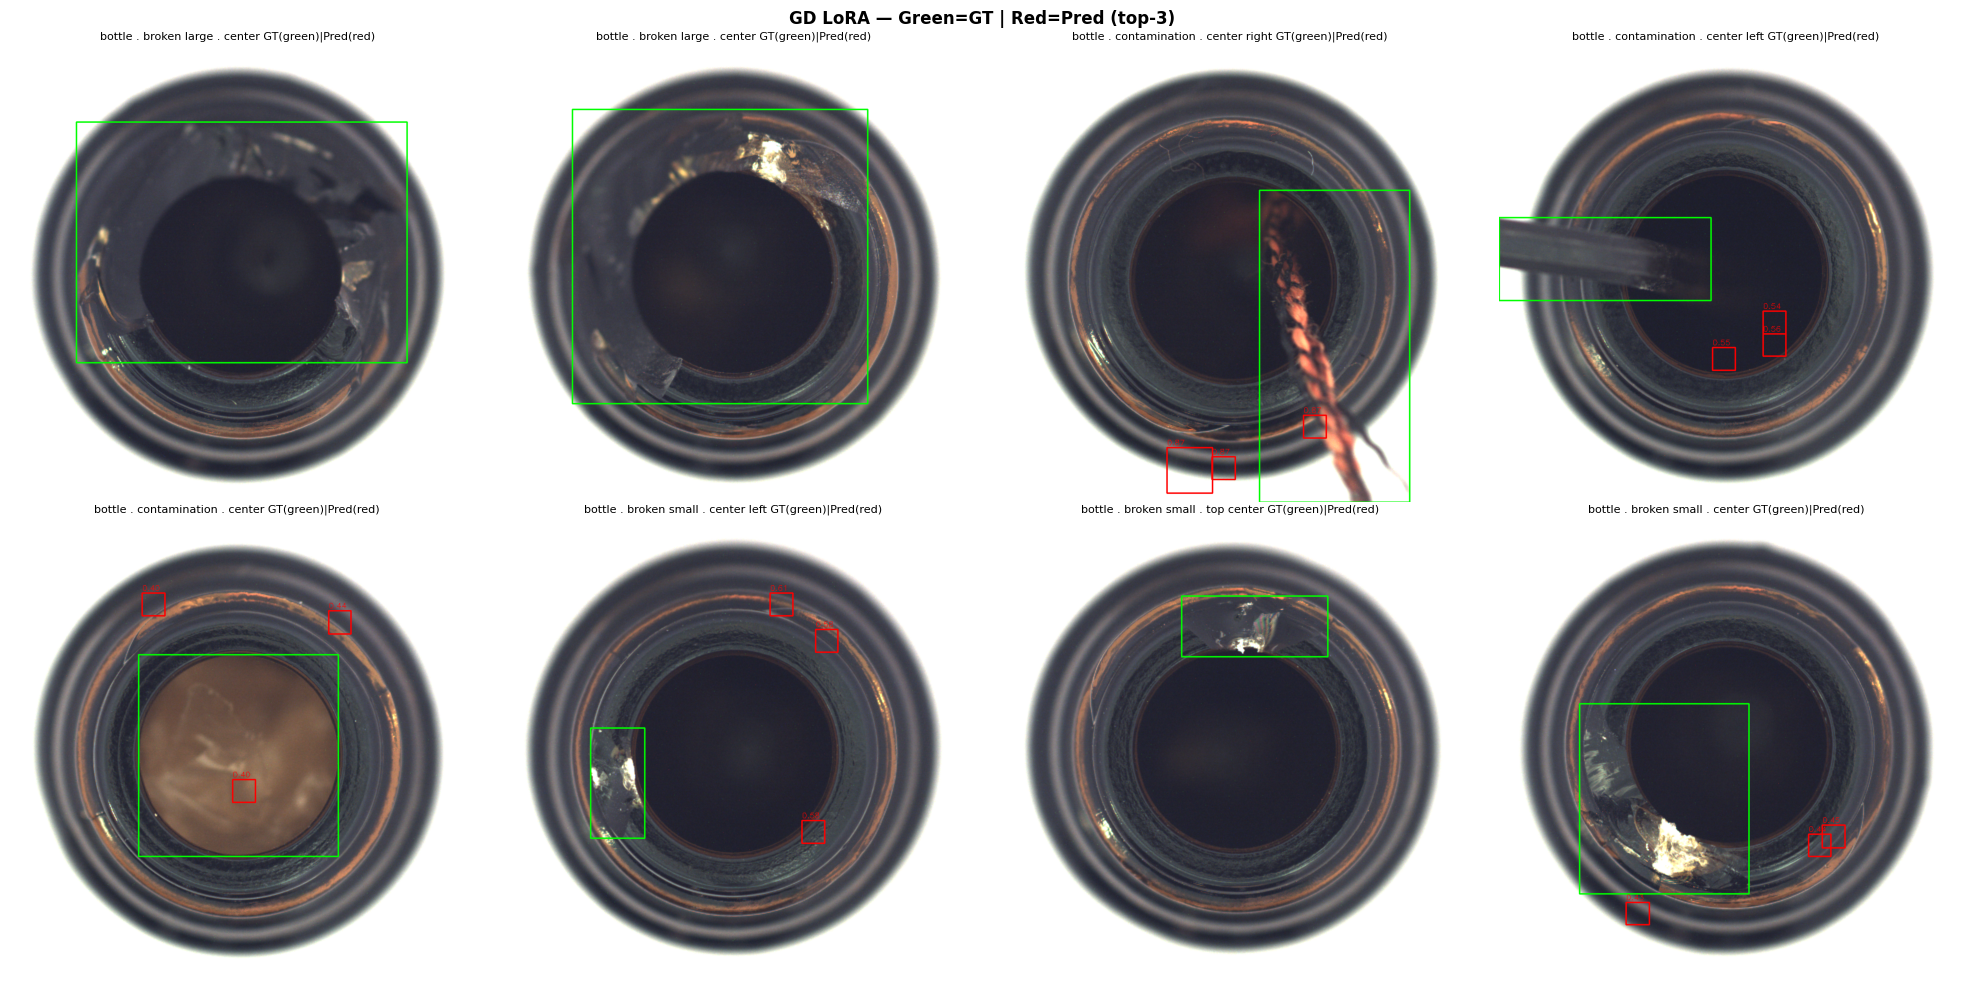

In [18]:
# Visualize predictions (dung dung ham tu Cell 16)
import cv2, matplotlib.pyplot as plt, numpy as np
from PIL import Image

def load_img_pil(path):
    img = Image.open(path).convert("RGB")
    return img, np.array(img)

# Lay defect samples tu eval JSON
import json as _json
with open("/content/drive/MyDrive/AIP491/output/dataset_eval.json") as f:
    eval_data = _json.load(f)
defect_samples = [s for s in eval_data if len(s.get("bboxes",[]))>0 and s.get("split") in ("test","val")]
print(f"Defect samples: {len(defect_samples)}")

n_show = min(8, len(defect_samples))
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, item in enumerate(defect_samples[:n_show]):
    img_raw, img_np = load_img_pil(item["original_path"])
    caption = build_query(item)
    pb, ps, (h, w) = run_inference(lora_model, item["original_path"], caption)

    # GT (green)
    for bbox in item["bboxes"]:
        x1,y1,x2,y2 = map(int, bbox)
        cv2.rectangle(img_np, (x1,y1),(x2,y2), (0,255,0), 2)
    # Pred (red) — top 3
    for bb, sc in zip(pb[:3], ps[:3]):
        x1,y1,x2,y2 = map(int, bb)
        cv2.rectangle(img_np, (x1,y1),(x2,y2), (255,0,0), 2)
        cv2.putText(img_np, f"{sc:.2f}", (x1, max(y1-5,10)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,0,0), 1)

    axes[i].imshow(img_np)
    axes[i].set_title(f"{caption[:40]} GT(green)|Pred(red)", fontsize=8)
    axes[i].axis("off")

plt.suptitle("GD LoRA — Green=GT | Red=Pred (top-3)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

In [19]:
# ── RESUME: Load checkpoint + continue training ──────────────────────────────────────────
# Chạy cell này SAU khi train xong epoch 1, muốn train thêm epoch
# THAY DOI: doi num_epochs = 5 (hoac so muon), roi chay Cell 15 lai

# # 1. Load base model (clone tu Cell 6)
# import sys
# sys.path.append("/content/GroundingDINO")
# from groundingdino.models import build_model
# from groundingdino.util.slconfig import SLConfig
#
# config_path = "/content/GroundingDINO/groundingdino/config/GroundingDINO_SwinT_OGC.py"
# args = SLConfig.fromfile(config_path)
# model = build_model(args)
# checkpoint = torch.load("/content/GroundingDINO/weights/groundingdino_swint_ogc.pth", map_location="cpu")
# model.load_state_dict(checkpoint["model"], strict=False)
# model = model.float()
#
# # 2. Apply patches (clone tu Cell 4)
# # ... paste Cell 4 patches here ...
#
# # 3. Setup LoRA (clone tu Cell 12)
# from peft import LoraConfig, get_peft_model
# model = model.float()
# for param in model.parameters():
#     param.requires_grad = False
# lora_config = LoraConfig(r=8, lora_alpha=16, target_modules=[...], lora_dropout=0.05, bias="none")
# model = get_peft_model(model, lora_config)
#
# # 4. Load trained LoRA weights tu checkpoint
# trained_state = torch.load("/content/drive/MyDrive/groundingdino_lora/best/adapter_model.safetensors", map_location="cpu")
# model.load_state_dict(trained_state, strict=False)
# model.to(device)
#
# # 5. DOI num_epochs = 5 TRONG CELL 15, roi chay lai Cell 15
# print("Checkpoint loaded. Chay Cell 15 de train tiep.")
